<a href="https://colab.research.google.com/github/DataCommanderUsher/Titanic---Machine-Learning-from-Disaster/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Author**: Usher Dube
* **Date**: 6 Dec 2025, 01:00
* **Descritption**: We are working on a begineer ML project from kaggle called Titanic - Machine Learning from Disaster
* **Link**: https://www.kaggle.com/competitions/titanic/data

In [1]:
#All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Read our train dataset, NAN on cabin
github_csv_url = 'https://raw.githubusercontent.com/DataCommanderUsher/Titanic---Machine-Learning-from-Disaster/main/train.csv'
train_df = pd.read_csv(github_csv_url)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Noticed NAN for age and its in float not integer
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
train_df.shape

(891, 12)

In [5]:
#Age has missing values, 714/891
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Considering the fact that man had to ensure safety of woman and children, it makes sense why most survived than man. That is shown by the stats below

In [6]:
survival_rate_by_sex = train_df.groupby('Sex')['Survived'].mean().reset_index()
print(survival_rate_by_sex)

      Sex  Survived
0  female  0.742038
1    male  0.188908


/tmp/ipython-input-1618040746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')


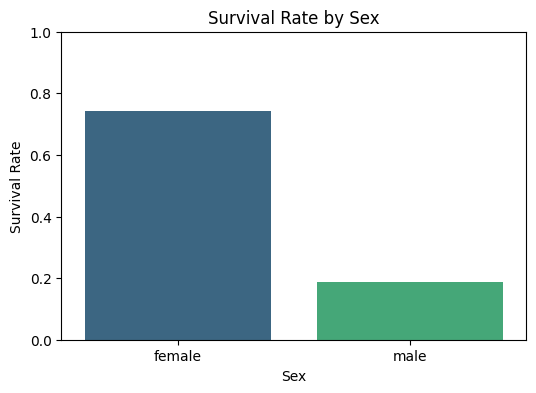

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

It appears more first-class people managed to survive compared to other classes, meaning they were proitized for survival

In [9]:
survival_rate_by_pclass = train_df.groupby('Pclass')['Survived'].mean().reset_index()
print(survival_rate_by_pclass)

   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


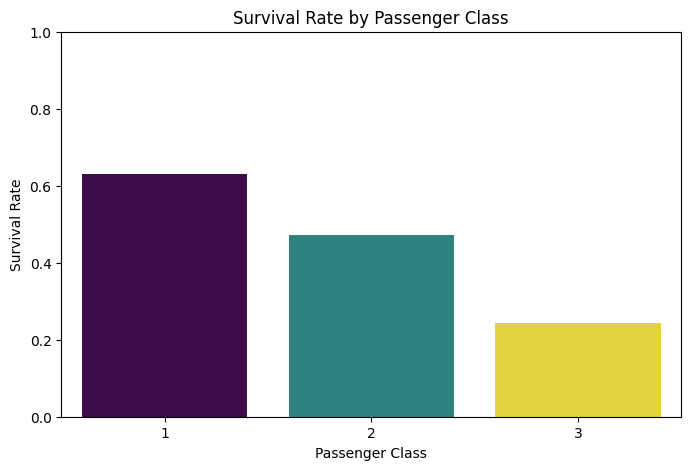

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_rate_by_pclass, palette='viridis', hue='Pclass', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Set y-axis limit to represent proportion/rate
plt.show()

In [17]:
#Replace NAN with median
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

/tmp/ipython-input-3837728605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)


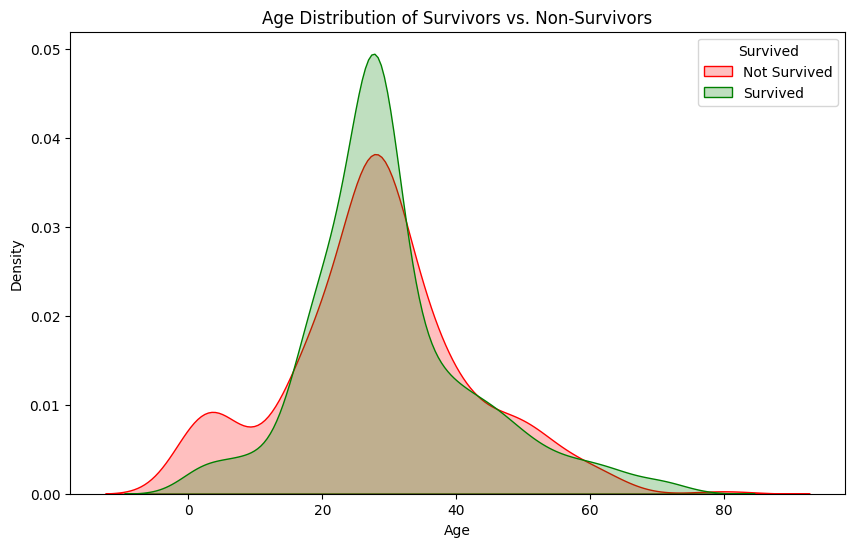

In [20]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x='Age', hue='Survived', fill=True, common_norm=False, palette={0: 'green', 1: 'red'})
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.show()

In [21]:
#Replace the two missing values in embarked with the mode
most_frequent_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_frequent_embarked)

In [15]:
survival_rate_by_embarked = train_df.groupby('Embarked')['Survived'].mean().reset_index()
print(survival_rate_by_embarked)

  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009


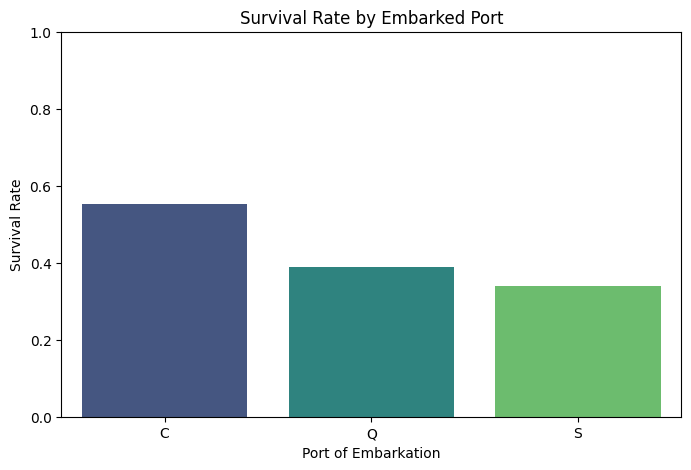

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=survival_rate_by_embarked, palette='viridis', hue='Embarked', legend=False)
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

## Summary of Survival Rate Analysis

Based on the visualizations and analyses of the `train_df` dataset, the following key insights regarding passenger survival rates can be observed:

*   **Survival Rate by Sex**: There was a significant disparity in survival rates between genders. Females had a much higher survival rate (around 74%) compared to males (around 19%). This suggests that being female was a strong predictor of survival.

*   **Survival Rate by Pclass**: Passenger class played a crucial role in survival. First-class passengers had the highest survival rate (around 63%), followed by second-class passengers (around 47%), and third-class passengers had the lowest survival rate (around 24%). This indicates that socio-economic status, or the class of travel, was a significant factor in survival, possibly due to preferential treatment or better access to lifeboats.

*   **Survival Rate by Age Distribution**: The KDE plots revealed differences in age distributions between survivors and non-survivors. It appears that younger passengers, especially children, had a higher chance of survival. There might also be a slight increase in survival for some older age groups, but generally, the density of non-survivors was higher across most adult age ranges. The median age was used to impute missing values, ensuring a complete age analysis.

*   **Survival Rate by Embarked Port**: The port of embarkation also showed some correlation with survival rates. Passengers who embarked from Cherbourg (C) had the highest survival rate (around 55%), followed by Queenstown (Q) with approximately 39%, and Southampton (S) with the lowest survival rate (around 34%). This could be influenced by the demographic characteristics of passengers embarking from each port, including their class and gender distribution.

In [23]:
survival_rate_by_parch = train_df.groupby('Parch')['Survived'].mean().reset_index()
print(survival_rate_by_parch)

   Parch  Survived
0      0  0.343658
1      1  0.550847
2      2  0.500000
3      3  0.600000
4      4  0.000000
5      5  0.200000
6      6  0.000000


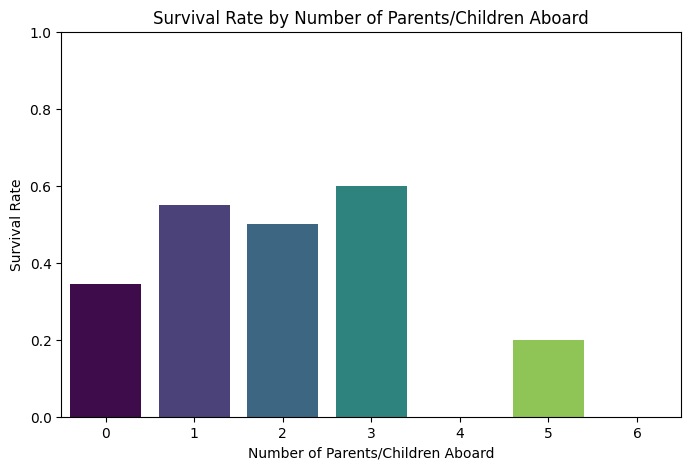

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Parch', y='Survived', data=survival_rate_by_parch, palette='viridis', hue='Parch', legend=False)
plt.title('Survival Rate by Number of Parents/Children Aboard')
plt.xlabel('Number of Parents/Children Aboard')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Set y-axis limit to represent proportion/rate
plt.show()

In [25]:
survival_rate_by_sibsp = train_df.groupby('SibSp')['Survived'].mean().reset_index()
print(survival_rate_by_sibsp)

   SibSp  Survived
0      0  0.345395
1      1  0.535885
2      2  0.464286
3      3  0.250000
4      4  0.166667
5      5  0.000000
6      8  0.000000


**Reasoning**:
Now that the survival rates by 'SibSp' are calculated, I will generate a bar plot to visualize these rates, including a title, labels, and setting the y-axis limits as per the instructions.



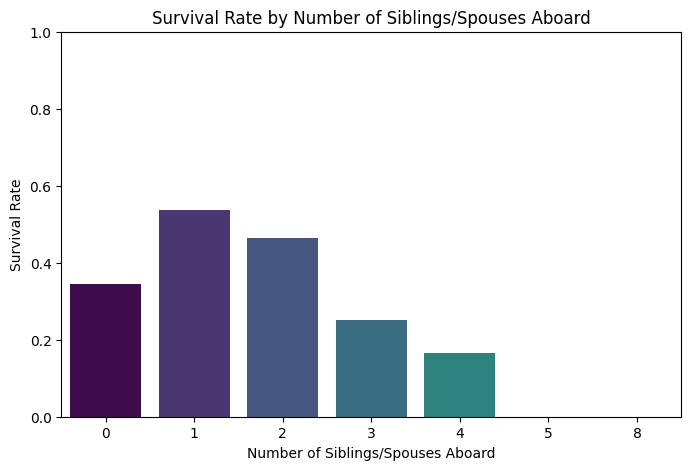

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x='SibSp', y='Survived', data=survival_rate_by_sibsp, palette='viridis', hue='SibSp', legend=False)
plt.title('Survival Rate by Number of Siblings/Spouses Aboard')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Set y-axis limit to represent proportion/rate
plt.show()

In [27]:
train_df['Fare_Bin'] = pd.qcut(train_df['Fare'], 4, labels=False)
print("Created 'Fare_Bin' column:")
print(train_df[['Fare', 'Fare_Bin']].head())

Created 'Fare_Bin' column:
      Fare  Fare_Bin
0   7.2500         0
1  71.2833         3
2   7.9250         1
3  53.1000         3
4   8.0500         1


**Reasoning**:
Now that the 'Fare_Bin' column has been created, I will calculate the mean survival rate for each fare bin category and print the resulting DataFrame to display these survival rates.



In [28]:
survival_rate_by_fare_bin = train_df.groupby('Fare_Bin')['Survived'].mean().reset_index()
print(survival_rate_by_fare_bin)

   Fare_Bin  Survived
0         0  0.197309
1         1  0.303571
2         2  0.454955
3         3  0.581081


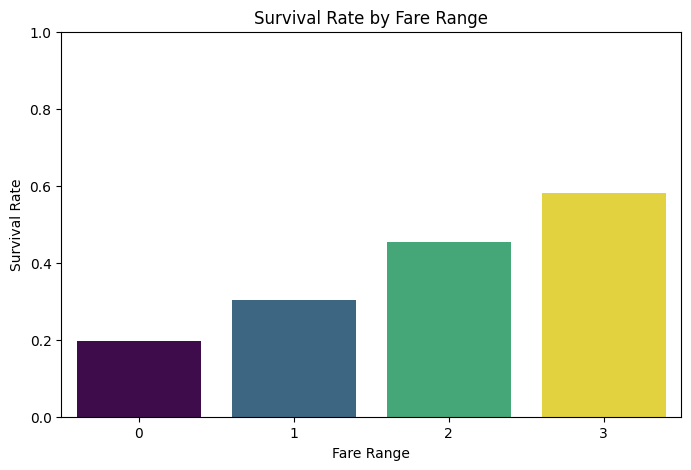

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Fare_Bin', y='Survived', data=survival_rate_by_fare_bin, palette='viridis', hue='Fare_Bin', legend=False)
plt.title('Survival Rate by Fare Range')
plt.xlabel('Fare Range')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

## Advanced Visualization: Survival by Family Size (SibSp + Parch) and Sex

### Subtask:
Create a new feature 'FamilySize' by combining 'SibSp' and 'Parch', then generate a visualization to show the survival rate based on 'FamilySize' and 'Sex'. The plot will include a legend and appropriate labels.


**Reasoning**:
The first instruction is to create a new column named 'FamilySize' in the `train_df` DataFrame by summing the 'SibSp' and 'Parch' columns. I will create a code block to achieve this.



In [30]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch']
print("Created 'FamilySize' column:")
print(train_df[['SibSp', 'Parch', 'FamilySize']].head())

Created 'FamilySize' column:
   SibSp  Parch  FamilySize
0      1      0           1
1      1      0           1
2      0      0           0
3      1      0           1
4      0      0           0


In [31]:
survival_rate_by_family_sex = train_df.groupby(['FamilySize', 'Sex'])['Survived'].mean().reset_index()
print("Survival rate by FamilySize and Sex:")
print(survival_rate_by_family_sex.head())

Survival rate by FamilySize and Sex:
   FamilySize     Sex  Survived
0           0  female  0.785714
1           0    male  0.155718
2           1  female  0.816092
3           1    male  0.243243
4           2  female  0.775510


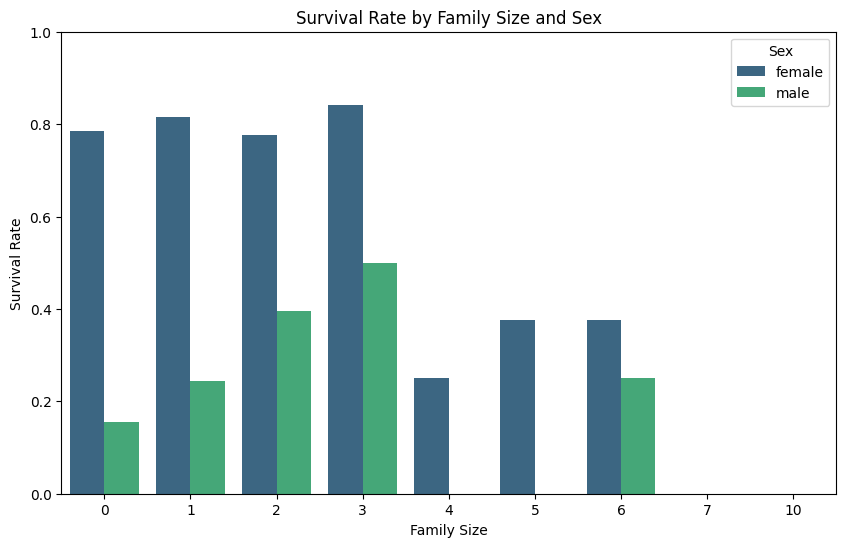

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x='FamilySize', y='Survived', hue='Sex', data=survival_rate_by_family_sex, palette='viridis')
plt.title('Survival Rate by Family Size and Sex')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.legend(title='Sex')
plt.show()